In [ ]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

df = pd.read_csv("trimmed-data-1.csv")

X = df.drop(columns=["Municipal", "Is Demolished", "Name"])
y = df["Municipal"]
X = pd.get_dummies(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(random_state=42, scale_pos_weight=807/175)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      0.91      0.90       160
        True       0.58      0.51      0.54        37

    accuracy                           0.84       197
   macro avg       0.73      0.71      0.72       197
weighted avg       0.83      0.84      0.83       197



In [2]:
model = XGBClassifier(
    random_state=42,
    scale_pos_weight=807/175,
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.87      0.82      0.85       160
        True       0.38      0.46      0.41        37

    accuracy                           0.76       197
   macro avg       0.62      0.64      0.63       197
weighted avg       0.78      0.76      0.77       197



In [3]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba >= 0.3).astype(bool)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

       False       0.92      0.57      0.71       160
        True       0.30      0.78      0.43        37

    accuracy                           0.61       197
   macro avg       0.61      0.68      0.57       197
weighted avg       0.80      0.61      0.66       197



In [4]:
y_pred_adjusted = (y_proba >= 0.4).astype(bool)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

       False       0.91      0.76      0.83       160
        True       0.39      0.68      0.50        37

    accuracy                           0.74       197
   macro avg       0.65      0.72      0.66       197
weighted avg       0.81      0.74      0.76       197



In [5]:
# filter to undesignated buildings
undesignated = df[df["Municipal"] == False].copy()

# prepare features the same way as training
X_undesignated = undesignated.drop(columns=["Municipal"])
X_undesignated = pd.get_dummies(X_undesignated)

# align columns with training data in case get_dummies created different columns
X_undesignated = X_undesignated.reindex(columns=X_train.columns, fill_value=0)

# get probabilities
undesignated["probability"] = model.predict_proba(X_undesignated)[:, 1]

# rank by probability
results = undesignated[["Name", "Community", "Year of Construction", "probability"]].sort_values("probability", ascending=False)
print(results.head(20))
results.to_csv("results-basic.csv")

#Results of model are above (the ones displayed in the app)

                                 Name                 Community  \
255                 Court House No. 2  DOWNTOWN COMMERCIAL CORE   
215     Central Memorial Park Library                  BELTLINE   
24             7 Street NW Boulevards                  ROSEDALE   
116      Bow Valley Lawn Bowling Club                 HILLHURST   
464         Hotel Cecil (Cecil Hotel)     DOWNTOWN EAST VILLAGE   
881               Substation No. Four             SOUTH CALGARY   
562         Louise (Hillhurst) Bridge                 HILLHURST   
760            Rotary Park Lawn Bowls          CRESCENT HEIGHTS   
266                     Crescent Park          CRESCENT HEIGHTS   
57             Allen (Palace) Theatre  DOWNTOWN COMMERCIAL CORE   
615                     Mewata Bridge                 HILLHURST   
59                Anderson Apartments         LOWER MOUNT ROYAL   
361  Fort Calgary Archaeological Site     DOWNTOWN EAST VILLAGE   
979                              YWCA                  BELTLIN

In [6]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

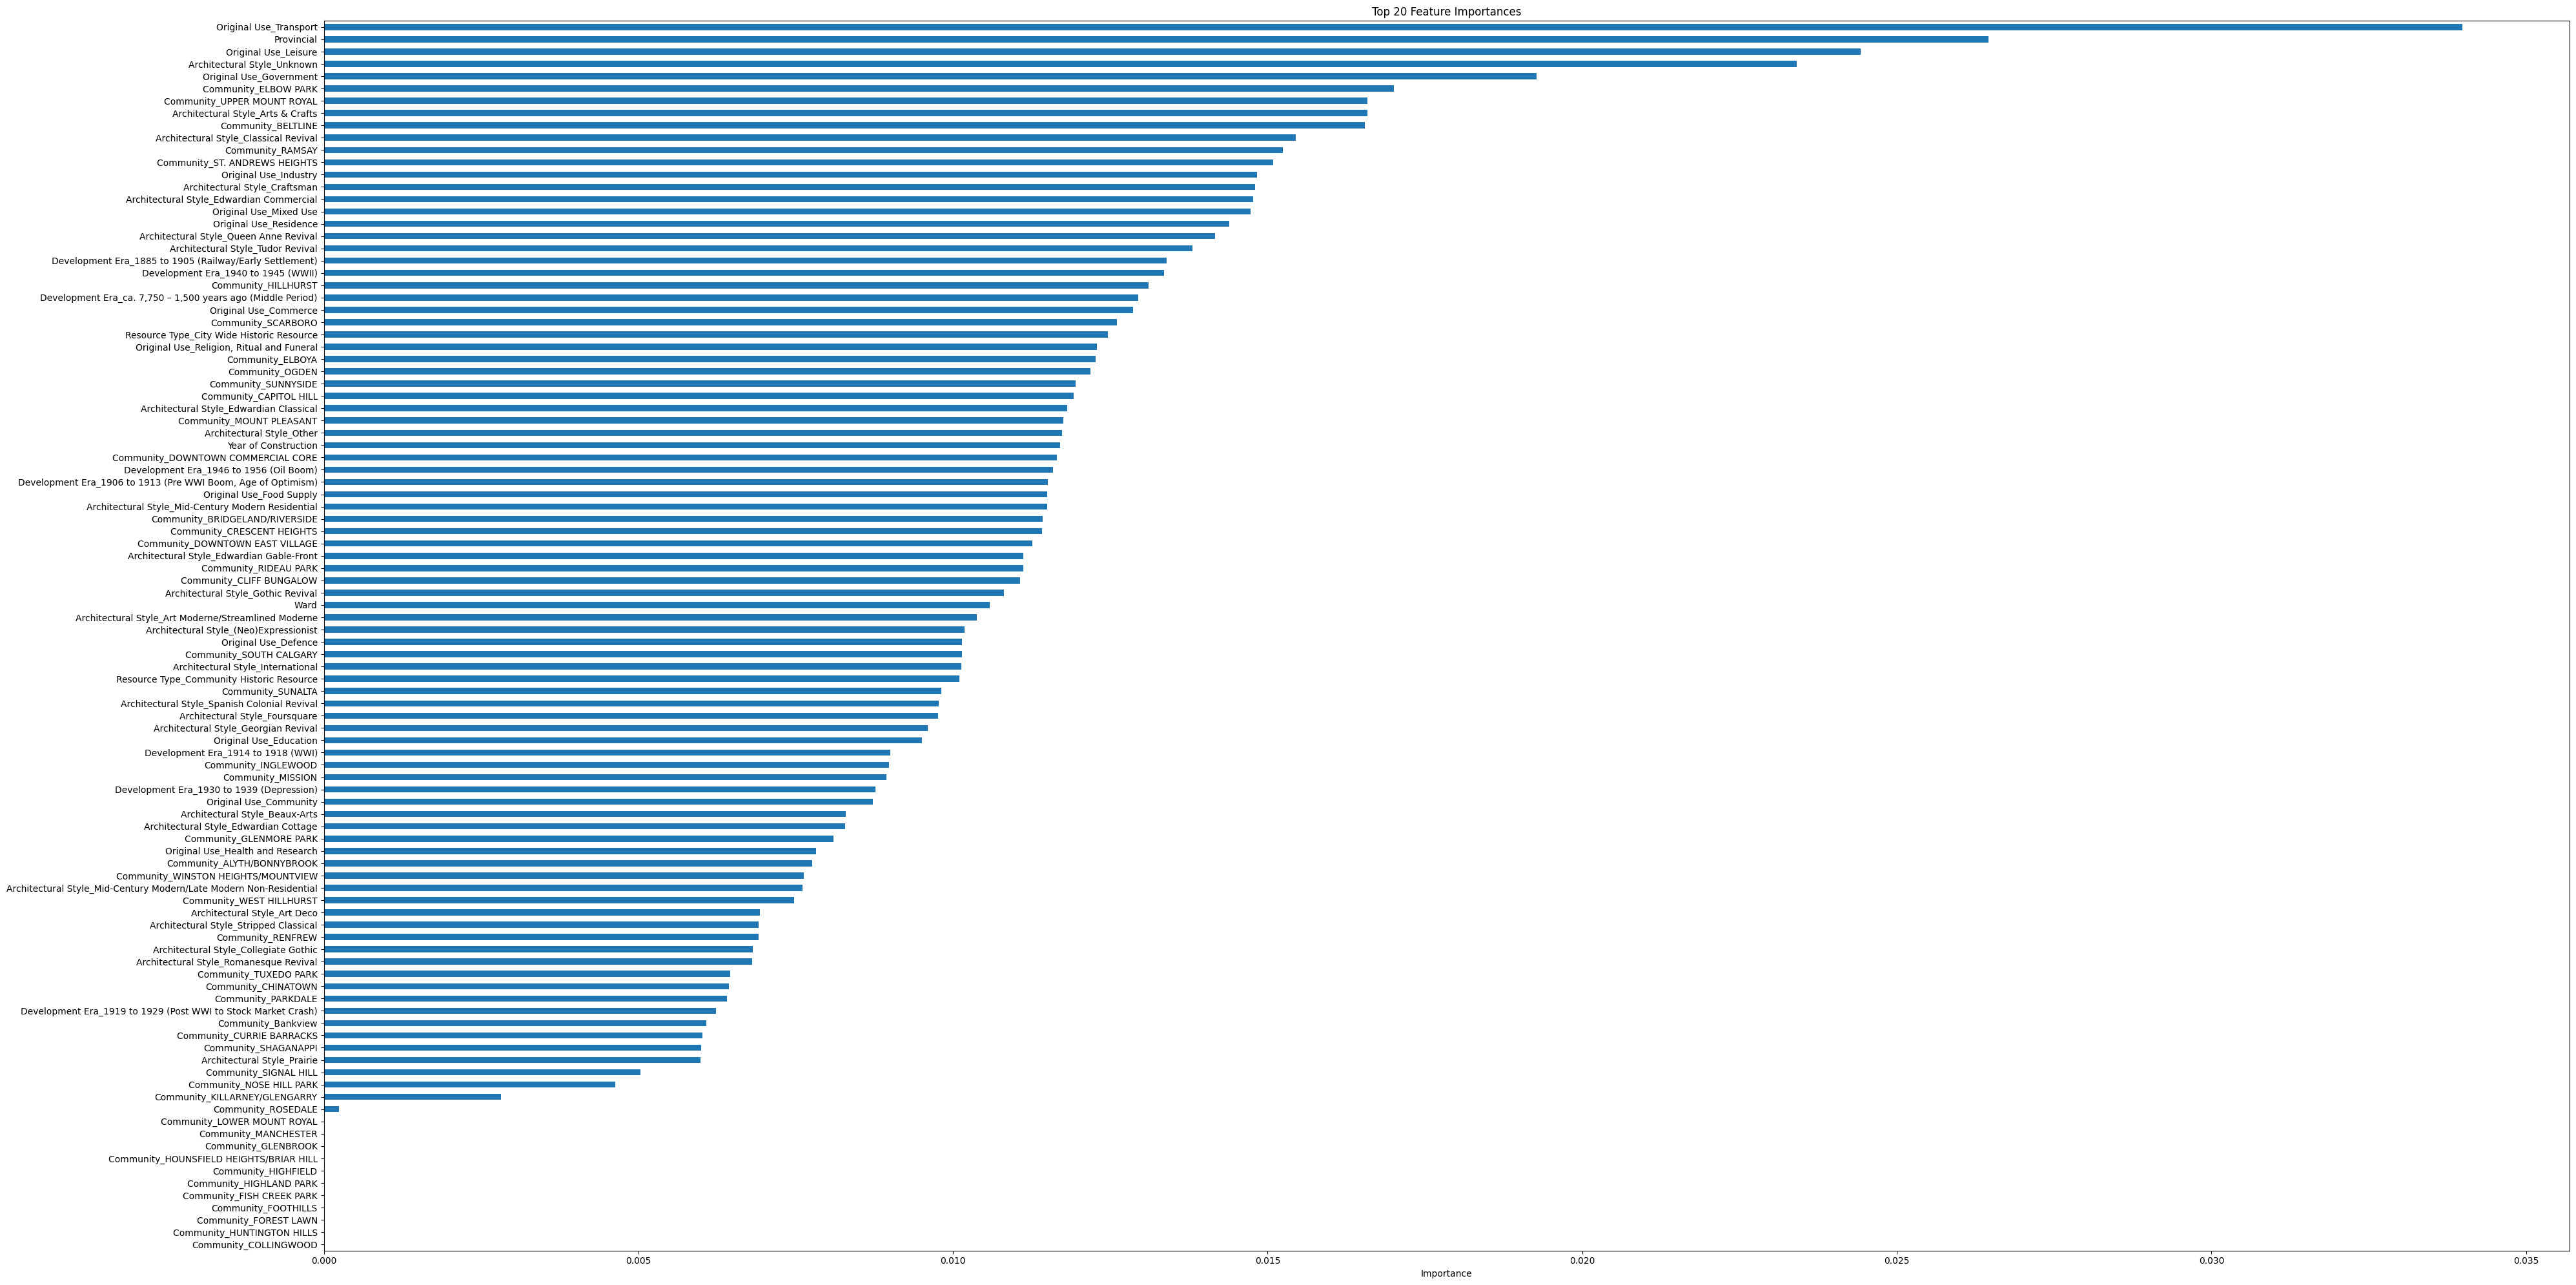

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(100)

feature_importance.plot(kind="barh", figsize=(40, 20))
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(20).to_string())
print(feature_importance.iloc[0])  # top feature name and value
print(feature_importance.index[0])

Original Use_Transport                                     0.033992
Provincial                                                 0.026452
Original Use_Leisure                                       0.024421
Architectural Style_Unknown                                0.023409
Original Use_Government                                    0.019275
Community_ELBOW PARK                                       0.017006
Community_UPPER MOUNT ROYAL                                0.016583
Architectural Style_Arts & Crafts                          0.016583
Community_BELTLINE                                         0.016544
Architectural Style_Classical Revival                      0.015442
Community_RAMSAY                                           0.015244
Community_ST. ANDREWS HEIGHTS                              0.015086
Original Use_Industry                                      0.014830
Architectural Style_Craftsman                              0.014802
Architectural Style_Edwardian Commercial        

In [9]:
print(feature_importance.index[0], feature_importance.iloc[0])

Original Use_Transport 0.033991683


In [10]:
y_train_pred = model.predict(X_train)
print("Train:")
print(classification_report(y_train, y_train_pred))
print("Test:")
print(classification_report(y_test, y_pred))

Train:
              precision    recall  f1-score   support

       False       0.96      0.86      0.91       647
        True       0.57      0.85      0.68       138

    accuracy                           0.86       785
   macro avg       0.77      0.86      0.80       785
weighted avg       0.89      0.86      0.87       785

Test:
              precision    recall  f1-score   support

       False       0.87      0.82      0.85       160
        True       0.38      0.46      0.41        37

    accuracy                           0.76       197
   macro avg       0.62      0.64      0.63       197
weighted avg       0.78      0.76      0.77       197



In [11]:
# We can see that our training data is getting 100% recall, need to generalize more

model = XGBClassifier(
    random_state=42,
    scale_pos_weight=807/175,
    max_depth=3,        # shallower trees = less memorization
    min_child_weight=5, # require more samples per leaf
    subsample=0.8,      # use 80% of data per tree
    colsample_bytree=0.8, # use 80% of features per tree
    reg_alpha=0.1,      # L1 regularization
    reg_lambda=1.0      # L2 regularization
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.87      0.82      0.85       160
        True       0.38      0.49      0.43        37

    accuracy                           0.76       197
   macro avg       0.63      0.65      0.64       197
weighted avg       0.78      0.76      0.77       197



In [12]:
y_train_pred = model.predict(X_train)
print("Train:")
print(classification_report(y_train, y_train_pred))
print("Test:")
print(classification_report(y_test, y_pred))

Train:
              precision    recall  f1-score   support

       False       0.96      0.83      0.89       647
        True       0.51      0.83      0.63       138

    accuracy                           0.83       785
   macro avg       0.74      0.83      0.76       785
weighted avg       0.88      0.83      0.85       785

Test:
              precision    recall  f1-score   support

       False       0.87      0.82      0.85       160
        True       0.38      0.49      0.43        37

    accuracy                           0.76       197
   macro avg       0.63      0.65      0.64       197
weighted avg       0.78      0.76      0.77       197



*Note* False positives in this case lead to wasted time/effort of the HC staff
  False Negatives means a potential missed site that would have designated.

  Prioritizing recall over precision means that we are prioritizing not missing potential site that would designate.

  Prioritizing precision would instead prioritize HC time

  Given that the inventory is relatively limited, missing a potential designation site seems worse than just wasting a bit of time/effort,
  Of course if they are prioritizing short term vs long term gains this could be different, but thinking longer term here.

  